In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
sc = spark.sparkContext

In [10]:
#1차원 데이터 생성
K=3
n=1000
max_iter = 10

X,y = make_blobs(n_samples=n, centers=K, n_features=1, cluster_std=1.0)
X = X.flatten()
rdd = sc.parallelize(X)

In [11]:
#1차원 가우시안 확률 함수 & 파라미터 초기화
#x:데이터, m:평균, v:분산
def gaussian_1d(x,m,v):
  v = np.maximum(v, 1e-6) #분산 0 방지
  norm_Factor = 1/np.sqrt(2*np.pi * v)
  exponent = -((x-m)**2) / (2*v)
  return norm_Factor * np.exp(exponent)

#파라미터 초기화
#평균mean: 랜덤하게 3개 찍음
mean = np.random.random((K,))*20-10
#분산var : 처음에는 1.0으로 시작
var = np.ones((K,))
#가중치pi : 랜덤 설정 후 정규화
pi = np.random.random((K,))
pi = pi / pi.sum()

In [12]:
#EM 알고리즘 구현
for i in range(max_iter):
  #브로드캐스팅
  b_pi = sc.broadcast(pi)
  b_mean = sc.broadcast(mean)
  b_var = sc.broadcast(var)

  #E step 시작 몇번 클러스터인지 확률 계산하는
  def compute_pcx_1d(x, pi, mean, var):
    probs = pi* gaussian_1d(x, mean, var)
    return probs / probs.sum()

  #(데이터, [소속 확률 3개])
  pcx_rdd = rdd.map(lambda x: (x, compute_pcx_1d(x, b_pi.value, b_mean.value, b_var.value)))

  #M step 시작
  #통계량 집계 (Reduce)
  # key: 클러스터 인덱스
  # value: (가중치 합, 가중치 합*x합, 가중치*x^2합)
  # 2d의 np.outer(x,x)가 1d에서는 x**2가 됨
  momentum_rdd = pcx_rdd.flatMap(lambda p:[
      (i, (p[1][i], p[1][i]*p[0], p[1][i]*(p[0]**2)))
      for i in range(K)
  ]).reduceByKey(lambda a, b : (a[0]+b[0], a[1]+b[1], a[2]+b[2]))

  #이제 파라미터들 갱신
  stats = momentum_rdd.collect()

  for i, (sum_w, sum_wx, sum_wxx) in stats:
    pi[i] = sum_w/n
    mean[i] = sum_wx/sum_w
    var[i] = (sum_wxx / sum_w) - (mean[i]**2) #제평-평제

  print(f"Iter {i+1}: Means = {mean}")

Iter 2: Means = [4.72615203 7.32115961 3.41125199]
Iter 2: Means = [5.02287698 7.3211596  3.45314938]
Iter 2: Means = [5.165445   7.32115959 3.43979265]
Iter 2: Means = [5.23862067 7.3211596  3.40996318]
Iter 2: Means = [5.27612506 7.3211596  3.36758236]
Iter 2: Means = [5.29474439 7.3211596  3.31295056]
Iter 2: Means = [5.30304257 7.32115961 3.26049298]
Iter 2: Means = [5.30550985 7.32115962 3.25114482]
Iter 2: Means = [5.30463451 7.32115963 3.25114482]
Iter 2: Means = [5.30188607 7.32115964 3.25114482]


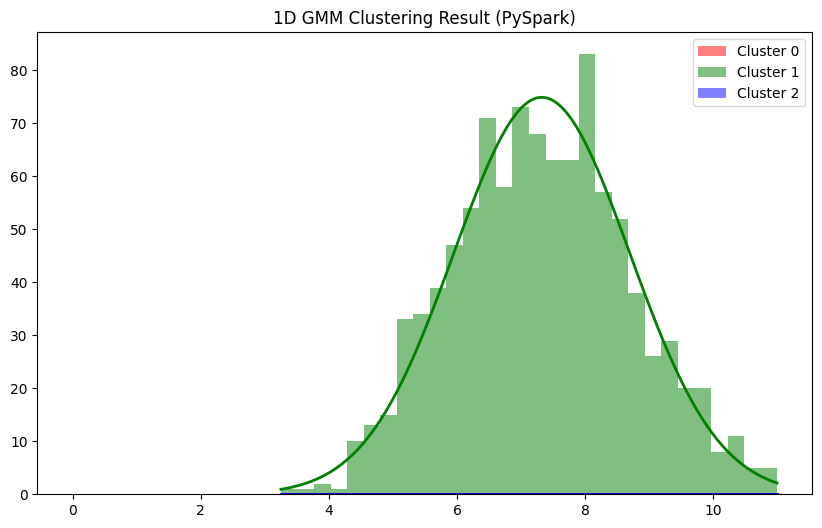

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 예측 (가장 확률 높은 클러스터 선택)
y_pred = [np.argmax(pi * gaussian_1d(x, mean, var)) for x in X]

# 시각화
df = pd.DataFrame({'x': X, 'cluster': y_pred})

plt.figure(figsize=(10, 6))

# 1. 데이터 히스토그램 (색깔별로)
colors = ['red', 'green', 'blue']
for k in range(K):
    subset = df[df['cluster'] == k]
    plt.hist(subset['x'], bins=30, alpha=0.5, color=colors[k], label=f'Cluster {k}')

# 2. 학습된 가우시안 분포 곡선 그리기
x_axis = np.linspace(min(X), max(X), 100)
for k in range(K):
    # 높이를 맞춰주기 위해 스케일 조정 (데이터 개수 * 가중치)
    plt.plot(x_axis, gaussian_1d(x_axis, mean[k], var[k]) * n * (max(X)-min(X))/30 * pi[k],
             color=colors[k], linewidth=2)

plt.title("1D GMM Clustering Result (PySpark)")
plt.legend()
plt.show()